In [6]:
import h5py
import numpy as np

In [7]:
reference_mat_file = r'E:\Thesis\thesis_code\data\rp\rp_ethernet_packets.mat'

In [8]:
with h5py.File(reference_mat_file, 'r') as f:
    reference_packet = np.array(f['packets'])  # shape: (recordLength,)
    # Access metadata
    metadata = f['metadata']
    sample_rate = metadata['sample_rate'][0][0]
    trigger_level = metadata['trigger_level'][0][0]
    record_length = metadata['record_length'][0][0]
    num_frames = metadata['num_frames'][0][0]

In [9]:
reference_packet = reference_packet[7, :]

In [10]:
reference_packet

array([-0.25683594, -0.31811523, -0.30566406, ..., -0.00073242,
       -0.00073242, -0.00073242], shape=(16384,))

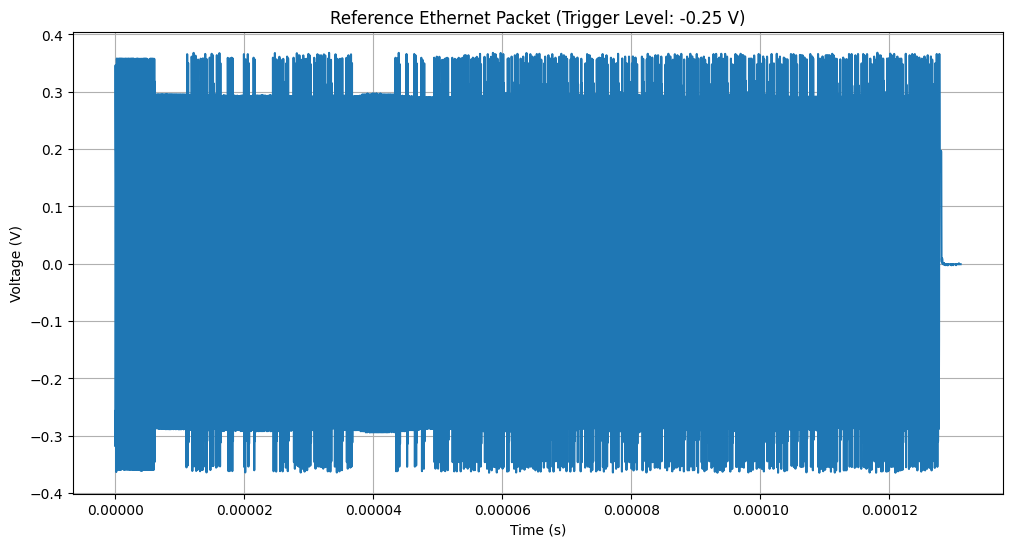

In [11]:
import matplotlib.pyplot as plt
import numpy as np

time_axis = np.arange(record_length) / sample_rate

plt.figure(figsize=(12,6))
plt.plot(time_axis, reference_packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [12]:
signal = reference_packet

In [13]:
def extract_packet(signal, threshold=0.2):
    # 1. Create boolean mask
    active = np.abs(signal) > threshold
    
    # 2. Find indices where active is True
    indices = np.where(active)[0]
    
    # 3. Handle case where no signal exceeds threshold
    if indices.size == 0:
        return np.array([]) # or return None
        
    # 4. Get start and end (add 1 to end for slicing)
    start = indices[0]
    end = indices[-1] + 1
    
    return signal[start:end]

# Usage
packet = extract_packet(signal, 0.1)

In [14]:
# import numpy as np

# # signal = your waveform
# threshold = 0.2

# active = np.abs(signal) > threshold

# start = np.argmax(active)
# end = len(signal) - np.argmax(active[::-1])

# packet = signal[start:end]

In [15]:
samples_per_bit = int(sample_rate / 10e6)  # 10Mbps
samples_per_bit

12

In [16]:
# print("Packet length (samples):", len(packet))
# print("Packet duration (s):", len(packet) / sample_rate)

# print("Packet duration (bits):", len(packet) / samples_per_bit)
# print("Packet duration (bytes):", len(packet) / (samples_per_bit * 8))
# print("Packet duration (frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Packet duration (Ethernet frames):", len(packet) / (samples_per_bit * 8 * 1500))
# print("Start index:", start)
# print("End index:", end)

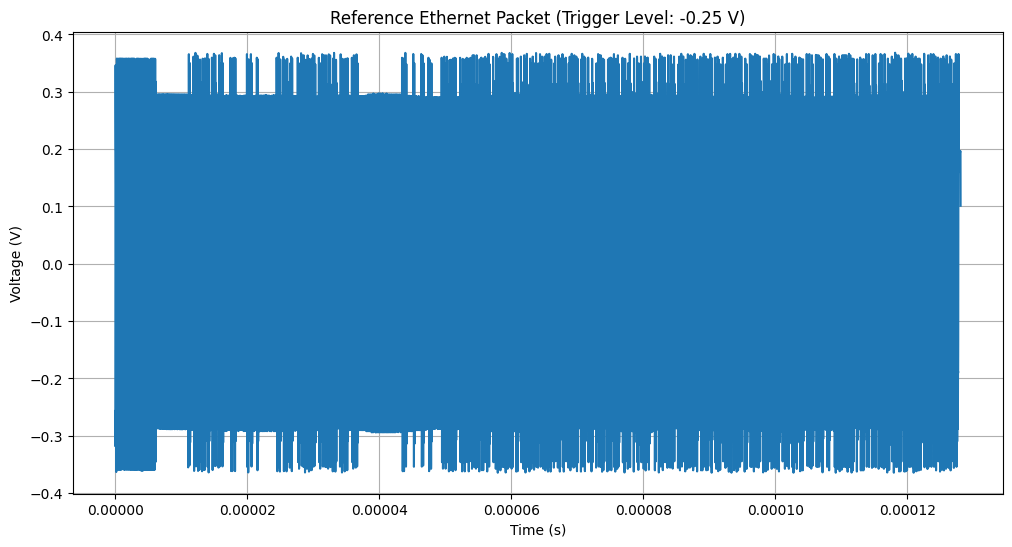

In [17]:
time_axis = np.arange(len(packet)) / sample_rate
plt.figure(figsize=(12,6))
plt.plot(time_axis, packet)
plt.title(f'Reference Ethernet Packet (Trigger Level: {trigger_level} V)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.grid(True)
plt.show()

In [18]:
packet[:200]

array([-0.25683594, -0.31811523, -0.30566406, -0.20263672, -0.01782227,
        0.13110352,  0.26293945,  0.34265137,  0.34631348,  0.27868652,
        0.21228027,  0.19885254,  0.19848633,  0.19848633,  0.17871094,
        0.13757324,  0.04833984, -0.08459473, -0.20251465, -0.32653809,
       -0.36328125, -0.32080078, -0.23132324, -0.19140625, -0.1887207 ,
       -0.18676758, -0.18139648, -0.14916992, -0.09448242,  0.03320312,
        0.15368652,  0.27807617,  0.35803223,  0.35522461,  0.28015137,
        0.21069336,  0.19702148,  0.19494629,  0.19299316,  0.17602539,
        0.13708496,  0.04663086, -0.08654785, -0.20275879, -0.32312012,
       -0.35961914, -0.32019043, -0.23120117, -0.19140625, -0.18701172,
       -0.18652344, -0.18139648, -0.14746094, -0.09265137,  0.03186035,
        0.15185547,  0.27600098,  0.35778809,  0.35693359,  0.28198242,
        0.2109375 ,  0.19714355,  0.19494629,  0.19299316,  0.17602539,
        0.13537598,  0.04797363, -0.08789062, -0.20483398, -0.32

In [19]:
packet[:67+125]

array([-0.25683594, -0.31811523, -0.30566406, -0.20263672, -0.01782227,
        0.13110352,  0.26293945,  0.34265137,  0.34631348,  0.27868652,
        0.21228027,  0.19885254,  0.19848633,  0.19848633,  0.17871094,
        0.13757324,  0.04833984, -0.08459473, -0.20251465, -0.32653809,
       -0.36328125, -0.32080078, -0.23132324, -0.19140625, -0.1887207 ,
       -0.18676758, -0.18139648, -0.14916992, -0.09448242,  0.03320312,
        0.15368652,  0.27807617,  0.35803223,  0.35522461,  0.28015137,
        0.21069336,  0.19702148,  0.19494629,  0.19299316,  0.17602539,
        0.13708496,  0.04663086, -0.08654785, -0.20275879, -0.32312012,
       -0.35961914, -0.32019043, -0.23120117, -0.19140625, -0.18701172,
       -0.18652344, -0.18139648, -0.14746094, -0.09265137,  0.03186035,
        0.15185547,  0.27600098,  0.35778809,  0.35693359,  0.28198242,
        0.2109375 ,  0.19714355,  0.19494629,  0.19299316,  0.17602539,
        0.13537598,  0.04797363, -0.08789062, -0.20483398, -0.32

In [20]:
packet = packet - np.mean(packet)

In [21]:
digital = packet > 0

In [22]:
digital[:100]

array([False, False, False, False, False,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
       False, False, False, False, False, False, False, False, False,
       False, False,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False, False, False, False, False, False, False,
       False])

In [23]:
digital = digital.astype(int)

In [24]:
edges = np.where(np.diff(digital) != 0)[0]

In [25]:
edges

array([    4,    16,    28, ..., 15947, 15954, 15966], shape=(2003,))

In [26]:
edge_distances = np.diff(edges)

In [27]:
edge_distances

array([12, 12, 13, ...,  6,  7, 12], shape=(2002,))

In [28]:
bit_distance = 12.5
tolerance = 2
relevant_edges = [edges[0]]  # Start with the first edge

In [29]:
i = 0
while i < len(edge_distances):
    if abs(edge_distances[i] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+1])  # Store the index of the edge
        i += 1  # Move to next edge
    elif i+1 < len(edge_distances) and abs(edge_distances[i] + edge_distances[i+1] - bit_distance) <= tolerance:
        relevant_edges.append(edges[i+2])  # Store the index of the edge
        i += 2  # Move to the next pair of edges
    else:
        print(f"Unexpected edge distance at index {i}: {edge_distances[i]} samples")
        i += 1  # Move to next edge

In [30]:
relevant_edges[-3:]

[np.int64(15941), np.int64(15954), np.int64(15966)]

In [31]:
bits = []

for e in relevant_edges:
    if digital[e] == 0 and digital[e+1] == 1:
        bits.append(1)     # rising edge
    elif digital[e] == 1 and digital[e+1] == 0:
        bits.append(0)     # falling edge
    else:
        raise ValueError(f"Unexpected edge at index {e}: digital[{e}]={digital[e]}, digital[{e+1}]={digital[e+1]}")

In [32]:
len(bits)

1278

In [33]:
bits

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,


In [34]:
bits[:64]

[1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1]

In [35]:
bitstring = ''.join(map(str,bits))

idx = bitstring.find("10101010101010101010101010101010101010101010101010101011")

print("packet start bit:", idx)

packet start bit: 6


In [36]:
def find_sfd(bits):

    pattern = [1,0]*7 + [1,1]  # 10101011
    
    for i in range(len(bits)-len(pattern)):
        if bits[i:i+len(pattern)] == pattern:
            return i + len(pattern)

    return None

In [37]:
payload_start_bit = find_sfd(bits)
print("payload start bit:", payload_start_bit)

payload start bit: 62


In [38]:
start = 62

dest_bits = bits[start : start+48]
src_bits  = bits[start+48 : start+96]
type_bits = bits[start+96 : start+112]

payload_bits = bits[494 : -32]
crc_bits     = bits[-32:]

In [39]:
def bits_to_bytes(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte = (byte << 1) | bits[i+j]
        bytes_out.append(byte)
        
    return bytes_out

In [40]:
def bits_to_bytes_lsb(bits):
    bytes_out = []
    
    for i in range(0, len(bits), 8):
        byte = 0
        for j in range(8):
            if i + j < len(bits):
                byte |= (bits[i + j] << j)  # LSB first
        bytes_out.append(byte)
    
    return bytes_out

In [41]:
dest_mac = bits_to_bytes(dest_bits)
src_mac  = bits_to_bytes(src_bits)
eth_type = bits_to_bytes(type_bits)
payload  = bits_to_bytes_lsb(payload_bits)
crc      = bits_to_bytes(crc_bits)

In [42]:
payload_bits

[1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,


In [43]:
dest_mac

[255, 255, 255, 255, 255, 255]

In [44]:
len(payload), len(payload_bits)

(94, 752)

In [45]:
payload

[51,
 87,
 17,
 112,
 199,
 177,
 238,
 81,
 156,
 192,
 27,
 169,
 141,
 251,
 5,
 111,
 222,
 140,
 35,
 147,
 217,
 243,
 134,
 241,
 228,
 210,
 39,
 193,
 247,
 163,
 214,
 23,
 97,
 11,
 220,
 227,
 7,
 195,
 19,
 3,
 244,
 73,
 188,
 59,
 63,
 201,
 237,
 146,
 7,
 37,
 133,
 193,
 52,
 60,
 102,
 100,
 201,
 55,
 40,
 169,
 124,
 53,
 143,
 78,
 240,
 56,
 24,
 67,
 5,
 226,
 130,
 202,
 129,
 4,
 216,
 180,
 106,
 90,
 31,
 84,
 136,
 47,
 62,
 186,
 55,
 156,
 82,
 95,
 41,
 70,
 53,
 248,
 34,
 18]

In [46]:
samples_per_bit = int(sample_rate / 100e6)  # 100 Mbps
num_bits = len(digital) // samples_per_bit

In [47]:
payload

[51,
 87,
 17,
 112,
 199,
 177,
 238,
 81,
 156,
 192,
 27,
 169,
 141,
 251,
 5,
 111,
 222,
 140,
 35,
 147,
 217,
 243,
 134,
 241,
 228,
 210,
 39,
 193,
 247,
 163,
 214,
 23,
 97,
 11,
 220,
 227,
 7,
 195,
 19,
 3,
 244,
 73,
 188,
 59,
 63,
 201,
 237,
 146,
 7,
 37,
 133,
 193,
 52,
 60,
 102,
 100,
 201,
 55,
 40,
 169,
 124,
 53,
 143,
 78,
 240,
 56,
 24,
 67,
 5,
 226,
 130,
 202,
 129,
 4,
 216,
 180,
 106,
 90,
 31,
 84,
 136,
 47,
 62,
 186,
 55,
 156,
 82,
 95,
 41,
 70,
 53,
 248,
 34,
 18]